<a href="https://colab.research.google.com/github/Shavindri/Programming-for-Data-Analysis/blob/Masters/Programming_for_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Configure visual style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


In [2]:
# Load the Drive helper and mount
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
%cd "/content/drive/MyDrive/Assignment "


/content/drive/MyDrive/Assignment 


In [4]:
ls

 app.py         'Assessment Data-20251126'/      output/
 aqi_model.pkl  'Assessment Data-20251126.zip'


In [5]:
path = 'Assessment Data-20251126'   # Folder where the 12 monthly files are stored
files = [file for file in os.listdir(path) if file.endswith('.csv')]

all_data = pd.DataFrame()
for file in files:
    df = pd.read_csv(os.path.join(path, file))
    all_data = pd.concat([all_data, df])

all_data.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Jaipur,14/06/2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Jaipur,15/06/2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Jaipur,16/06/2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Jaipur,17/06/2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Jaipur,18/06/2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Read each CSV file and concatenate them into a single DataFrame
all_data = pd.DataFrame()
for file in files:
    file_path = os.path.join(path, file)
    df_temp = pd.read_csv(file_path)
    all_data = pd.concat([all_data, df_temp], ignore_index=True)

print('Combined data shape (rows, columns):', all_data.shape)
print("Number of files loaded:", len(files))
print("Total rows:", all_data.shape[0])
print("Total columns:", all_data.shape[1])


Combined data shape (rows, columns): (29531, 16)
Number of files loaded: 26
Total rows: 29531
Total columns: 16


In [7]:
all_data.describe().T

,count,mean,std,min,25%,50%,75%,max
PM2.5,24933.0,67.450578,64.661449,0.04,28.820,48.57,80.5900,949.99
PM10,18391.0,118.127103,90.605110,0.01,56.255,95.68,149.7450,1000.00
NO,25949.0,17.574730,22.785846,0.02,5.630,9.89,19.9500,390.68
NO2,25946.0,28.560659,24.474746,0.01,11.750,21.69,37.6200,362.21
NOx,25346.0,32.309123,31.646011,0.00,12.820,23.52,40.1275,467.63
NH3,19203.0,23.483476,25.684275,0.01,8.580,15.85,30.0200,352.89
CO,27472.0,2.248598,6.962884,0.00,0.510,0.89,1.4500,175.81
SO2,25677.0,14.531977,18.133775,0.01,5.670,9.16,15.2200,193.86
O3,25509.0,34.491430,21.694928,0.01,18.860,30.84,45.5700,257.73
Benzene,23908.0,3.280840,15.811136,0.00,0.120,1.07,3.0800,455.03


In [8]:
# Descriptive statistics for selected non-numeric columns
all_data.describe(include=['object']).T

,count,unique,top,freq
City,29531,26,Chennai,2009
Date,29531,2009,01/07/2020,26
AQI_Bucket,24850,6,Moderate,8829


In [9]:
all_data = pd.DataFrame()

for file in files:
    df = pd.read_csv(os.path.join(path, file))
    df['Source_File'] = file
    all_data = pd.concat([all_data, df], ignore_index=True)


In [10]:
all_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   City         29531 non-null  object 
 1   Date         29531 non-null  object 
 2   PM2.5        24933 non-null  float64
 3   PM10         18391 non-null  float64
 4   NO           25949 non-null  float64
 5   NO2          25946 non-null  float64
 6   NOx          25346 non-null  float64
 7   NH3          19203 non-null  float64
 8   CO           27472 non-null  float64
 9   SO2          25677 non-null  float64
 10  O3           25509 non-null  float64
 11  Benzene      23908 non-null  float64
 12  Toluene      21490 non-null  float64
 13  Xylene       11422 non-null  float64
 14  AQI          24850 non-null  float64
 15  AQI_Bucket   24850 non-null  object 
 16  Source_File  29531 non-null  object 
dtypes: float64(13), object(4)
memory usage: 3.8+ MB


In [11]:
# Normalize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)
df.columns.tolist()


['city',
 'date',
 'pm2.5',
 'pm10',
 'no',
 'no2',
 'nox',
 'nh3',
 'co',
 'so2',
 'o3',
 'benzene',
 'toluene',
 'xylene',
 'aqi',
 'aqi_bucket',
 'source_file']

In [12]:
#Missing values
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct': missing_pct
})
missing_summary

,missing_count,missing_pct
nh3,1560,92.91
xylene,1560,92.91
pm10,939,55.93
toluene,610,36.33
nox,452,26.92
benzene,442,26.33
aqi,226,13.46
aqi_bucket,226,13.46
so2,175,10.42
pm2.5,154,9.17


In [13]:
# Duplicates
print('Duplicate rows before:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('Duplicate rows after:', df.duplicated().sum())

# Drop columns with >60% missing
threshold = 0.6
thresh = int((1 - threshold) * len(df))  # keep columns with at least (1-threshold) non-null
print(f'Dropping columns with more than {int(threshold*100)}% missing...')
col_before = df.shape[1]
df = df.dropna(axis=1, thresh=thresh).copy()
col_after = df.shape[1]
print(f'Columns before: {col_before}, after: {col_after}')

Duplicate rows before: 0
Duplicate rows after: 0
Dropping columns with more than 60% missing...
Columns before: 17, after: 15


In [14]:
df = df.drop_duplicates().reset_index(drop=True)
target_col = None
for c in df.columns:
    if 'covid' in c and 'death' in c:
        target_col = c
        break

if target_col:
    q1 = df[target_col].quantile(0.25)
    q3 = df[target_col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[target_col] < lower) | (df[target_col] > upper)]
    outliers.shape


In [15]:
# Convert Date column to datetime and remove rows where conversion fails
all_data['Date'] = pd.to_datetime(all_data['Date'], errors='coerce')
all_data = all_data.dropna(subset=['Date'])

# Remove the duplicate rows
all_data = all_data.drop_duplicates().reset_index(drop=True)
print('Shape after removing invalid dates and duplicates:', all_data.shape)

Shape after removing invalid dates and duplicates: (29531, 17)


/tmp/ipython-input-522458999.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  all_data['Date'] = pd.to_datetime(all_data['Date'], errors='coerce')


In [16]:
# Numeric and categorical columns
numeric_cols = all_data.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = all_data.select_dtypes(include=['object']).columns.tolist()
print('Numeric columns:', numeric_cols)
print('Categorical columns:', categorical_cols)

Numeric columns: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']
Categorical columns: ['City', 'AQI_Bucket', 'Source_File']


In [17]:
# Impute missing values
for col in numeric_cols:
    median_value = all_data[col].median()
    all_data[col] = all_data[col].fillna(median_value)

for col in categorical_cols:
    all_data[col] = all_data[col].fillna(method='ffill')
    all_data[col] = all_data[col].fillna(method='bfill')

missing_after = all_data.isna().sum().sum()
print('Total remaining missing values:', missing_after)

Total remaining missing values: 0


/tmp/ipython-input-1924386814.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  all_data[col] = all_data[col].fillna(method='ffill')
/tmp/ipython-input-1924386814.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  all_data[col] = all_data[col].fillna(method='bfill')


In [18]:
# Create additional time based features
all_data['Year'] = all_data['Date'].dt.year
all_data['Month'] = all_data['Date'].dt.month
all_data['Day'] = all_data['Date'].dt.day
all_data['Season'] = all_data['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Summer', 4: 'Summer', 5: 'Summer',
    6: 'Monsoon', 7: 'Monsoon', 8: 'Monsoon',
    9: 'Post-Monsoon', 10: 'Post-Monsoon', 11: 'Post-Monsoon'
})
all_data[['Date', 'Year', 'Month', 'Season']].head()

,Date,Year,Month,Season
0,2017-06-14,2017,6,Monsoon
1,2017-06-15,2017,6,Monsoon
2,2017-06-16,2017,6,Monsoon
3,2017-06-17,2017,6,Monsoon
4,2017-06-18,2017,6,Monsoon


In [19]:
# Create a folder to store the cleaned dataset and have saved in that folder
import os
os.makedirs("output", exist_ok=True)
all_data.to_csv("output/air_quality_dataset.csv", index=False)



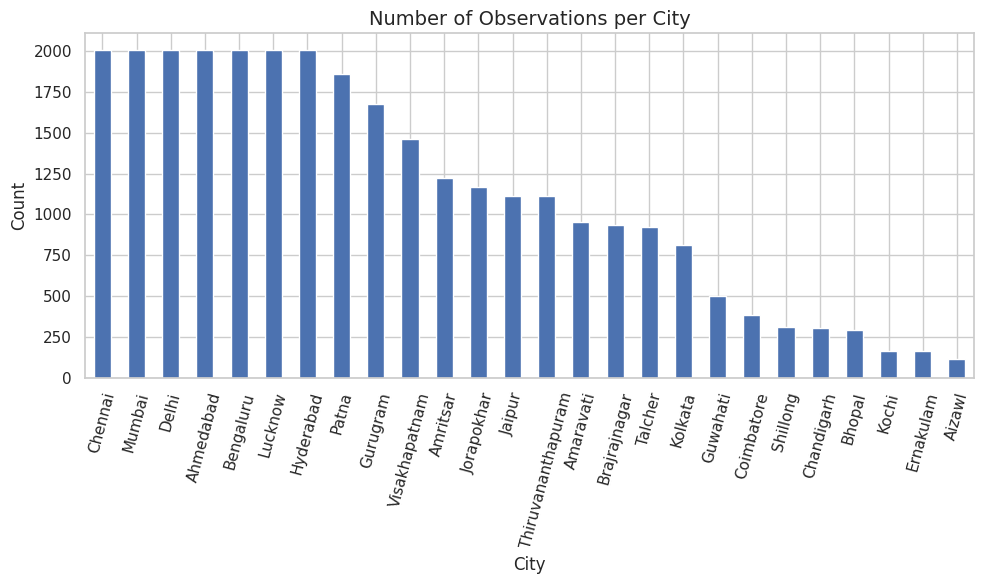

This bar chart shows how many air quality measurements are recorded in each city. 
It helps identify whether the dataset is balanced or if some cities have more monitoring data than others.
Uneven distribution may influence analysis results.


In [20]:
# Distribution of observations across cities

city_counts = all_data['City'].value_counts().sort_values(ascending=False)
plt.figure()
city_counts.plot(kind='bar')
plt.title('Number of Observations per City')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

print("This bar chart shows how many air quality measurements are recorded in each city. \nIt helps identify whether the dataset is balanced or if some cities have more monitoring data than others.\nUneven distribution may influence analysis results.")


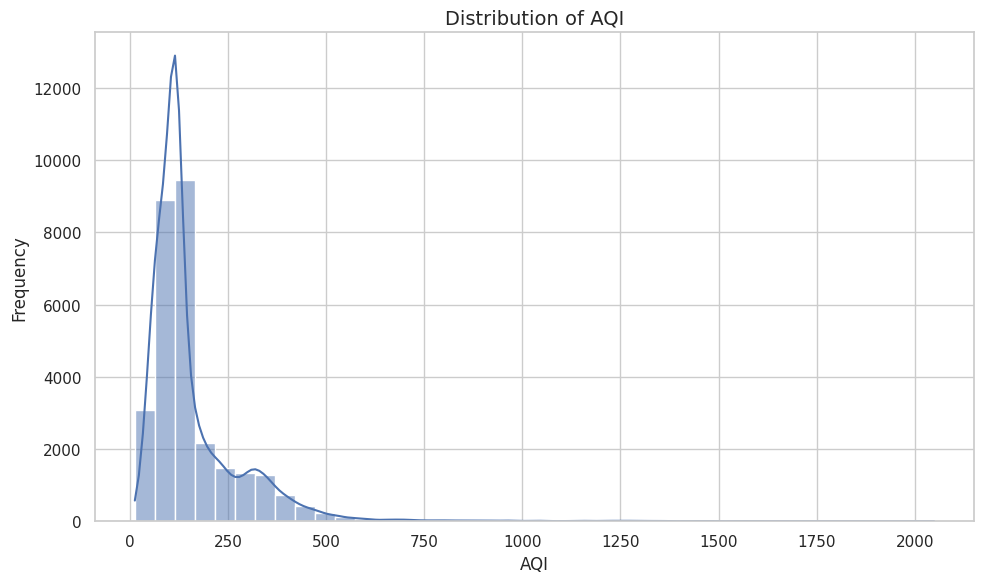

In [21]:
# Distribution of AQI values
plt.figure()
sns.histplot(all_data['AQI'], kde=True, bins=40)
plt.title('Distribution of AQI')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This histogram shows how AQI values are distributed in the dataset.
The majority of observations appear within the moderate range, with fewer readings
at extreme pollution levels. The KDE curve helps highlight the shape of the
distribution, showing whether AQI values are skewed toward cleaner or more polluted air.
Understanding this distribution is important because it reveals the general air
quality pattern across all cities and helps identify whether the dataset contains
frequent high-pollution events or mostly moderate conditions.


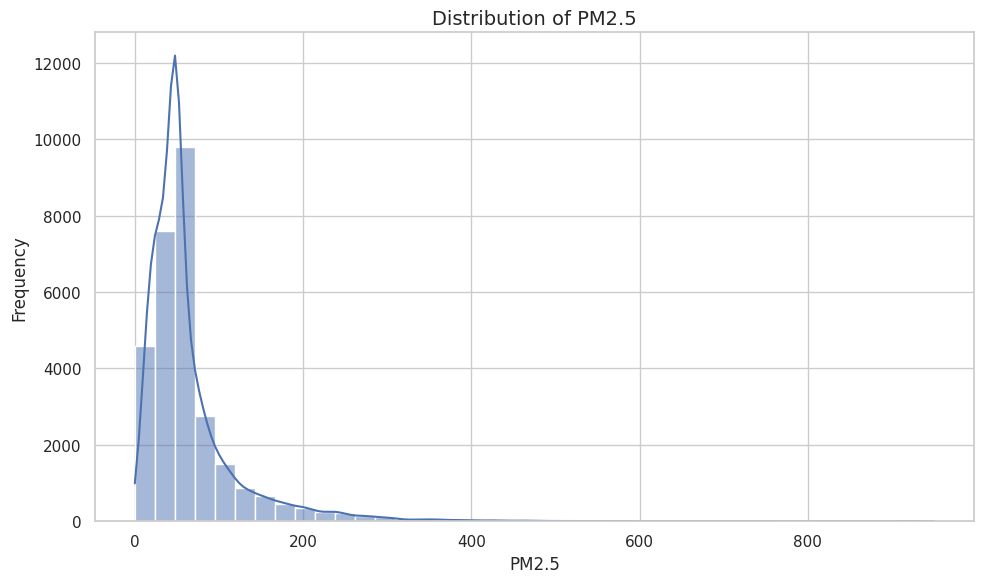

In [22]:
# Distribution of PM2.5 values
plt.figure()
sns.histplot(all_data['PM2.5'], kde=True, bins=40)
plt.title('Distribution of PM2.5')
plt.xlabel('PM2.5')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

The histogram illustrates the distribution of PM2.5 values in the dataset.
The majority of PM2.5 readings fall within the lower to moderate range, while a
smaller number of observations show very high concentrations, indicating pollution
spikes on certain days. The KDE curve highlights the density of values and reveals
whether the distribution is skewed.

Since PM2.5 is a major pollutant impacting AQI, understanding its distribution helps
identify how frequently dangerous pollution levels occur and whether the dataset
contains consistent patterns or occasional extreme events.


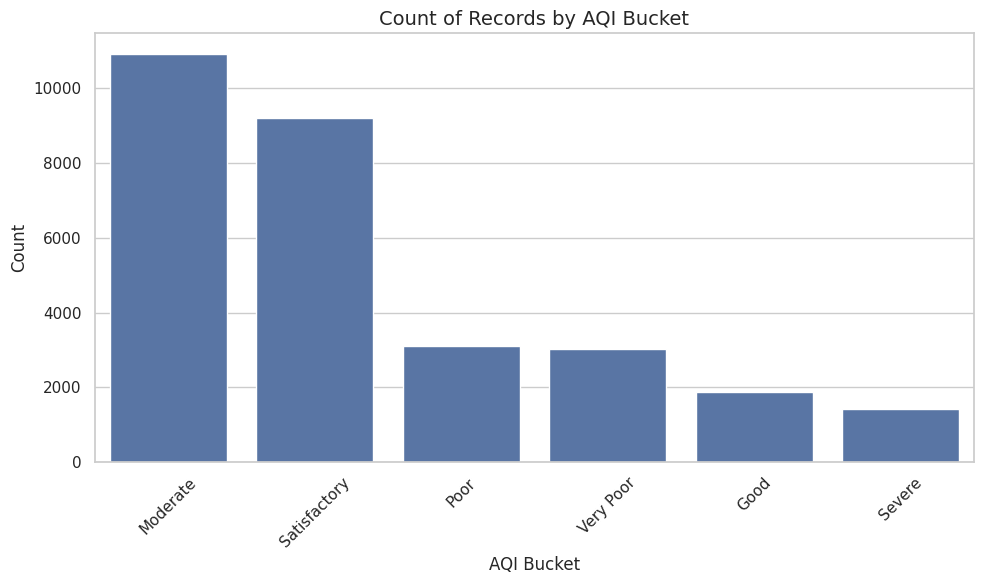

In [23]:
# Distribution of AQI buckets
plt.figure()
sns.countplot(data=all_data, x='AQI_Bucket', order=all_data['AQI_Bucket'].value_counts().index)
plt.title('Count of Records by AQI Bucket')
plt.xlabel('AQI Bucket')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This bar chart shows how many observations fall into each AQI category.
The distribution reveals which air quality levels occur most frequently in the dataset.
If categories such as “Moderate” or “Poor” contain most of the records, it suggests
that air quality is often below ideal levels. Meanwhile, a small count in “Good”
or “Severe” indicates infrequent extreme conditions.



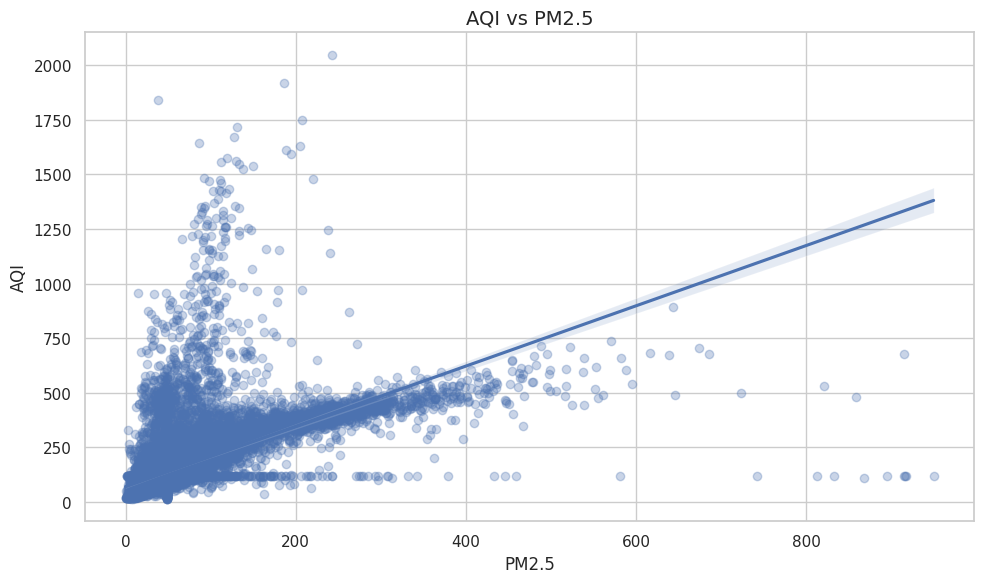

In [24]:
# Relationship between AQI and PM2.5
plt.figure()
sns.regplot(data=all_data, x='PM2.5', y='AQI', scatter_kws={'alpha': 0.3})
plt.title('AQI vs PM2.5')
plt.xlabel('PM2.5')
plt.ylabel('AQI')
plt.tight_layout()
plt.show()

This regression plot shows a clear positive relationship between PM2.5 and AQI.
As PM2.5 levels increase, AQI also tends to rise, indicating worsening air quality.
The upward-sloping regression line confirms PM2.5 as a strong predictor of AQI.



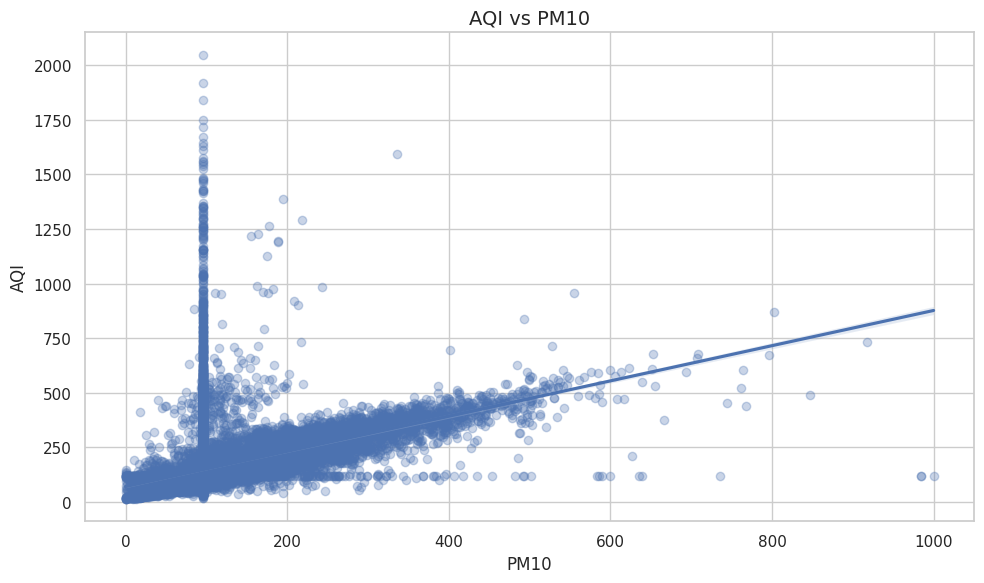

In [25]:
# Relationship between AQI and PM10
plt.figure()
sns.regplot(data=all_data, x='PM10', y='AQI', scatter_kws={'alpha': 0.3})
plt.title('AQI vs PM10')
plt.xlabel('PM10')
plt.ylabel('AQI')
plt.tight_layout()
plt.show()


This regression plot shows the relationship between PM10 levels and AQI.
The positive slope of the regression line indicates that higher PM10 concentrations
are associated with higher AQI values, meaning more polluted air.



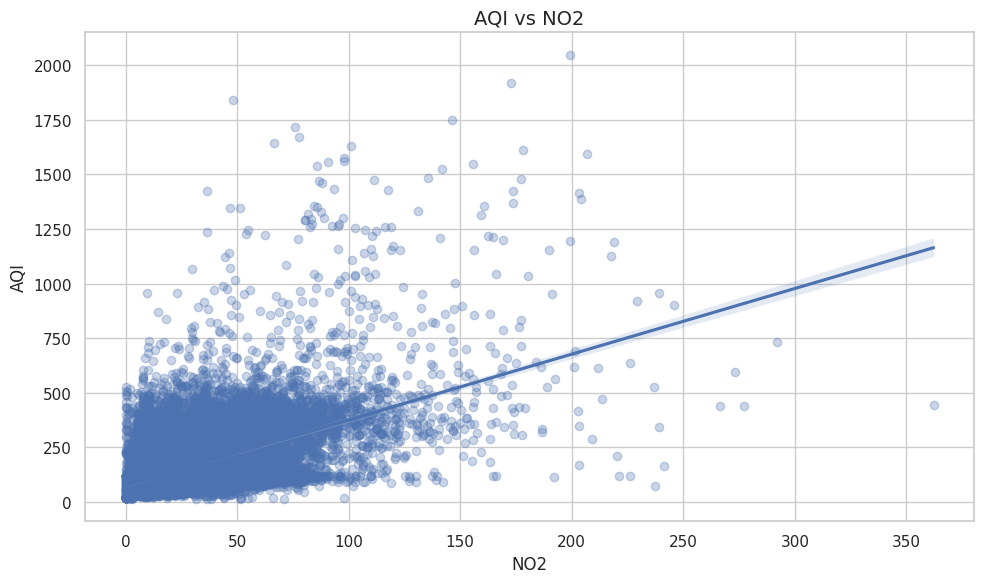

In [26]:
# Relationship between AQI and NO2
plt.figure()
sns.regplot(data=all_data, x='NO2', y='AQI', scatter_kws={'alpha': 0.3})
plt.title('AQI vs NO2')
plt.xlabel('NO2')
plt.ylabel('AQI')
plt.tight_layout()
plt.show()

This regression plot shows a positive correlation between NO2 levels and AQI.
As NO2 concentrations increase, AQI tends to rise, indicating that higher NO2 levels
are associated with poorer air quality.


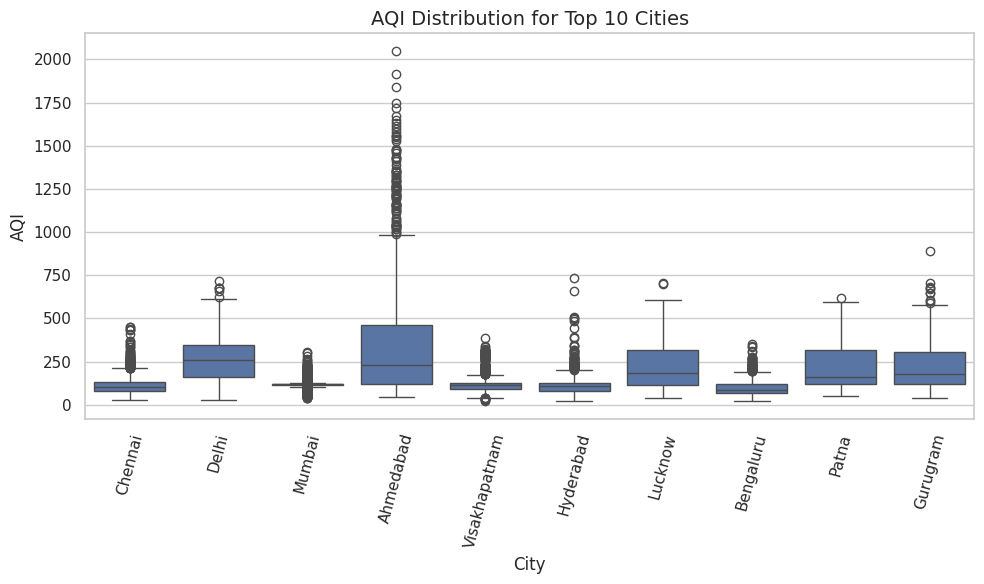

In [27]:
# Boxplot of AQI by city for the top 10 cities by number of records
top_cities = city_counts.head(10).index
plt.figure()
sns.boxplot(data=all_data[all_data['City'].isin(top_cities)], x='City', y='AQI')
plt.title('AQI Distribution for Top 10 Cities')
plt.xlabel('City')
plt.ylabel('AQI')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

This boxplot compares AQI distributions for the ten cities with the highest number
of observations in the dataset. The median line within each box shows the central
tendency of AQI for each city, while the box height represents variability.

Cities with higher median AQI values experience poorer air quality on average,
while cities with wide distributions or many outliers show more fluctuations in
pollution levels. Outliers represent days with unusually high or low AQI values.

This visual comparison helps identify which cities consistently have worse air quality
and which ones show more stable or variable pollution trends.


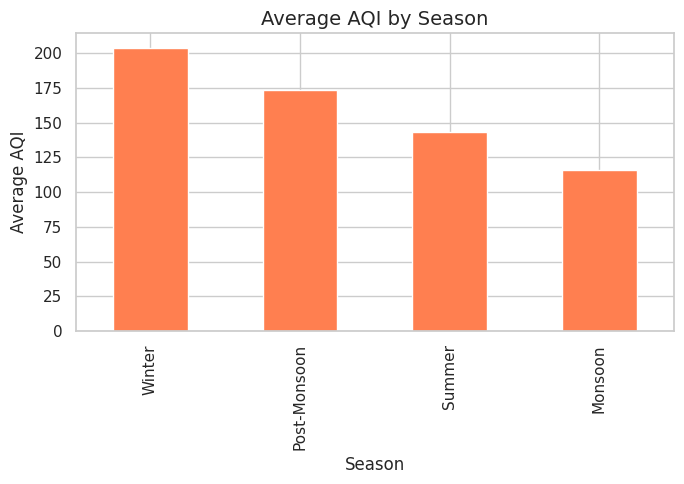

In [28]:
season_aqi = all_data.groupby('Season')['AQI'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
season_aqi.plot(kind='bar', color='coral')

plt.title('Average AQI by Season')
plt.xlabel('Season')
plt.ylabel('Average AQI')
plt.tight_layout()
plt.show()


This bar chart displays the average AQI for each season.
The results show clear seasonal variation in air quality. Some seasons record
higher mean AQI values, indicating poorer air quality, while others show cleaner
conditions.

Identifying which seasons have higher pollution levels
helps understand temporal patterns and can guide environmental policy and
preventive actions.


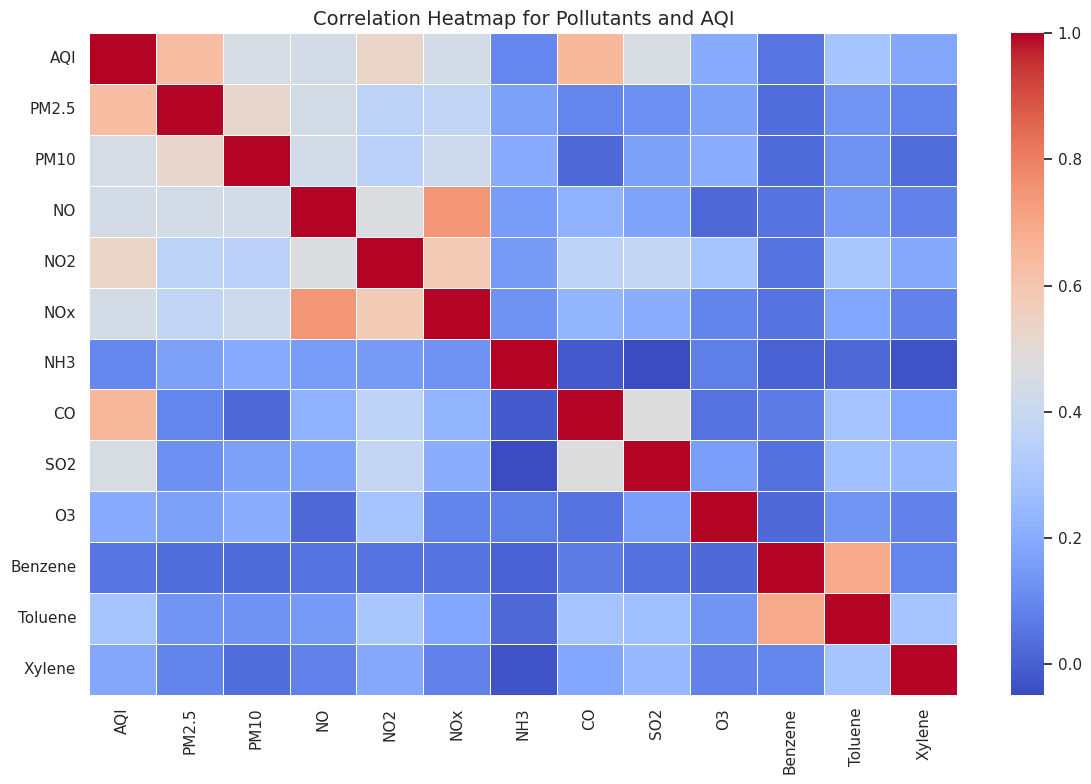

In [29]:
# Correlation matrix for key numeric variables
corr_cols = ['AQI', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
             'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

corr_cols = [c for c in corr_cols if c in all_data.columns]

corr_matrix = all_data[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap for Pollutants and AQI')
plt.tight_layout()
plt.show()

This correlation heatmap shows the strength and direction of the linear
relationships between AQI and major air pollutants. Warmer colours (red) represent
strong positive correlations, meaning that higher pollutant levels are associated
with higher AQI values. Cooler colours (blue) represent negative correlations or weak
relationships.

PM2.5 and CO typically show high positive correlations with AQI, indicating that these
pollutants have the strongest impact on air quality. Pollutants with weaker correlations
play a smaller role in determining AQI levels. Understanding these relationships helps
justify why certain features contribute more to the machine learning model and supports
data-driven decision-making in environmental monitoring.


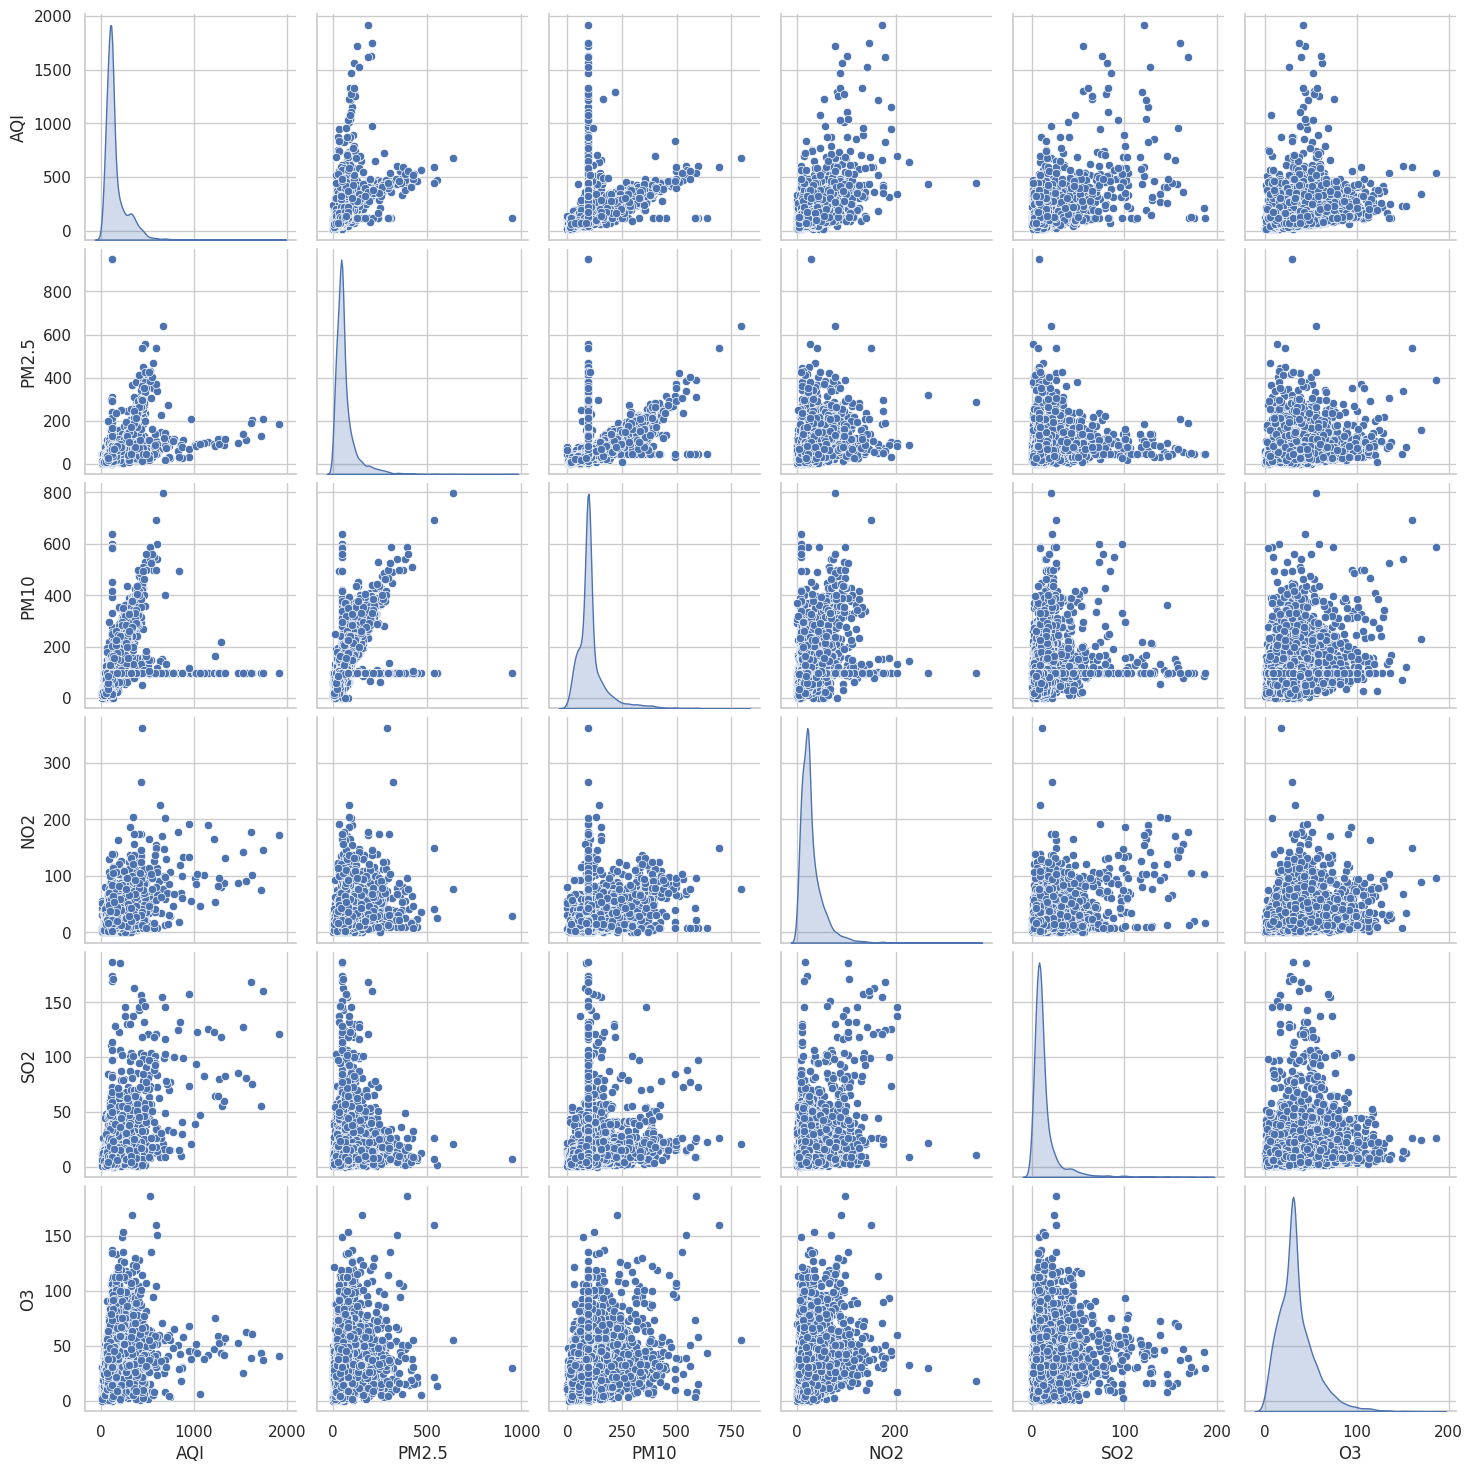

In [30]:
# Pairwise relationships between selected pollutants and AQI (sampled for speed)
sample_cols = ['AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'O3']
sample_cols = [c for c in sample_cols if c in all_data.columns]

# Sample up to 5000 rows to speed up plotting
sample_df = all_data[sample_cols].sample(
    min(5000, len(all_data)),
    random_state=42
)

sns.pairplot(sample_df, diag_kind='kde')
plt.show()

This pairplot shows the pairwise relationships between AQI and several major air pollutants
(PM2.5, PM10, NO2, SO2, and O3). The off-diagonal scatter plots reveal how each pollutant
correlates with AQI, while the diagonal KDE plots show the distribution shape of each variable.

The pairplot also helps identify multicollinearity between pollutants—for example, PM2.5 and
PM10 tend to show correlation with each other, which is important when selecting features for
machine learning models.


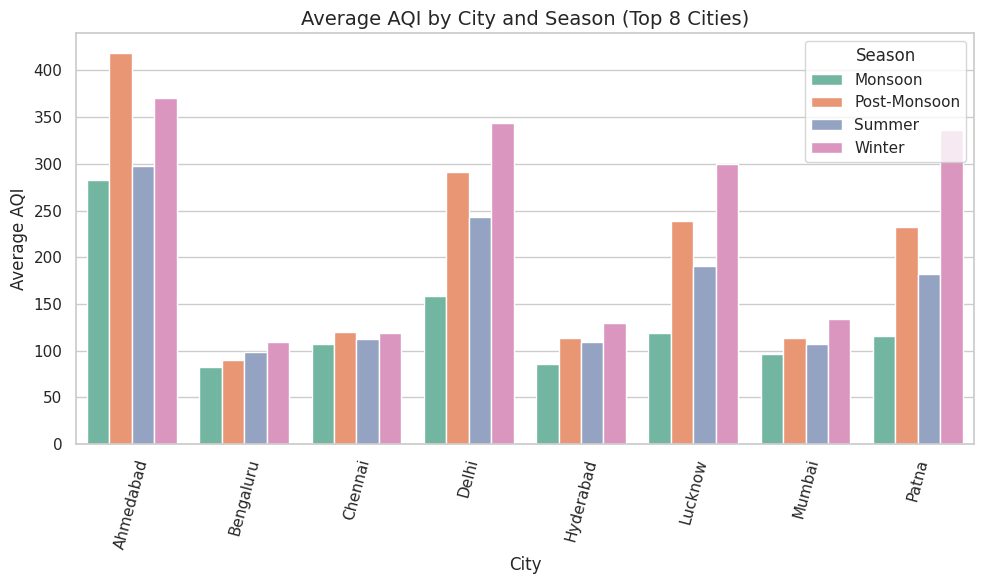

In [31]:
# Average AQI by city and season for the top 8 cities
top8_cities = city_counts.head(8).index

pivot_city_season = (
    all_data[all_data['City'].isin(top8_cities)]
    .groupby(['City', 'Season'])['AQI']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=pivot_city_season,
    x='City',
    y='AQI',
    hue='Season',
    palette='Set2'
)

plt.title('Average AQI by City and Season (Top 8 Cities)')
plt.xlabel('City')
plt.ylabel('Average AQI')
plt.xticks(rotation=75)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

This grouped bar chart compares the average AQI across seasons for the top
eight cities in the dataset. The results reveal both city-level and seasonal
variations in air quality.

By examining these seasonal patterns, we can understand not only which cities
experience the poorest air quality but also when pollution peaks occur, providing
valuable insights for environmental planning and public health measures.


/tmp/ipython-input-896595786.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')['AQI']


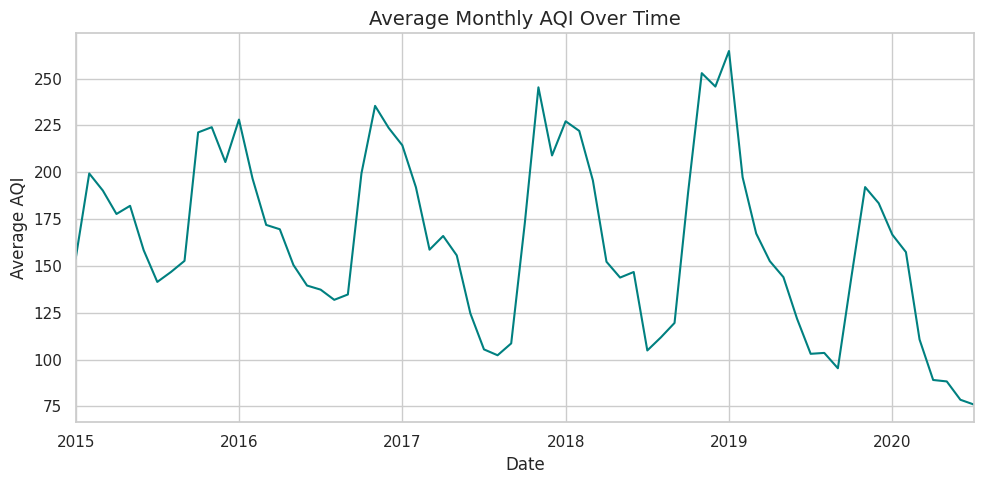

In [33]:
# Average monthly AQI over time
all_data['Date'] = pd.to_datetime(all_data['Date'], errors='coerce')

# Resample monthly and compute mean AQI
monthly_aqi = (
    all_data
    .set_index('Date')
    .resample('M')['AQI']
    .mean()
)

plt.figure(figsize=(10, 5))
monthly_aqi.plot(linewidth=1.5, color='teal')

plt.title('Average Monthly AQI Over Time')
plt.xlabel('Date')
plt.ylabel('Average AQI')
plt.tight_layout()
plt.show()


This line plot shows the average AQI for each month across the dataset.
By aggregating the data monthly, short-term noise is smoothed out, making
long-term trends easier to identify.

The graph reveals how air quality changes over time—whether it is improving,
worsening, or following a seasonal cycle. Peaks represent months with higher
pollution levels, while dips indicate periods of cleaner air. If the overall
trend rises, it suggests deteriorating air quality; if it falls, it indicates
improvement.


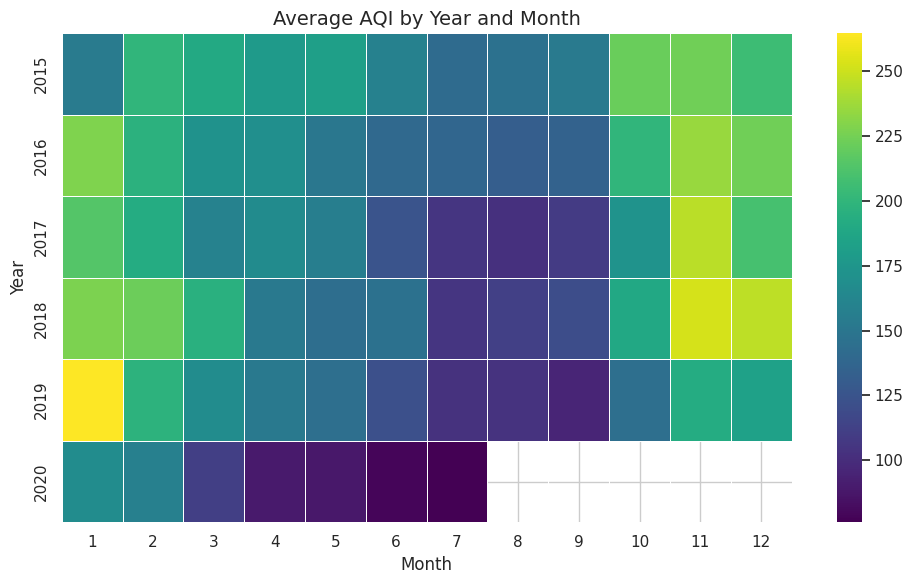

In [34]:
# Heatmap of average AQI by year and month
year_month_pivot = (
    all_data
    .groupby(['Year', 'Month'])['AQI']
    .mean()
    .reset_index()
)

year_month_table = year_month_pivot.pivot(
    index='Year',
    columns='Month',
    values='AQI'
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    year_month_table,
    annot=False,
    cmap='viridis',
    linewidths=0.5
)

plt.title('Average AQI by Year and Month')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

This heatmap illustrates the average AQI for each month across multiple years.
It highlights both seasonal patterns and long-term trends in air quality.

Horizontal patterns (across months) reveal seasonal behaviour.
For example, higher AQI in winter months may be caused by temperature inversion,
low wind speed, and increased heating activities, while monsoon months often show
lower AQI due to rain dispersing pollutants.

Vertical patterns (down the years) indicate whether air pollution is improving or
worsening over time. Darker colours in later years signal deteriorating air quality,
whereas lighter colours suggest improvement.

This visualisation provides a comprehensive understanding of how air quality varies
month-by-month and year-by-year, making it a useful tool for environmental monitoring
and policy planning.

Task 3


In [35]:
# Predicting AQI based on pollutant levels

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression



feature_cols = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO',
                'SO2','O3','Benzene','Toluene','Xylene']

target_col = 'AQI'

# Remove rows with missing pollutant or AQI values to avoid training errors
model_df = all_data.dropna(subset=[target_col] + feature_cols).copy()

X = model_df[feature_cols]
y = model_df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

# We split the dataset into training and testing sets so that we can train the model


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Random Forest does not require scaling, so we only standardize for LR.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression provides a simple interpretable baseline to compare performance.

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("\n===== Linear Regression Performance =====")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))
print("R² Score:", r2_score(y_test, lr_pred))



rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,            # Allow deep trees to learn patterns
    min_samples_split=2,       # Default split rule
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("\n===== Random Forest Performance =====")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("R² Score:", r2_score(y_test, rf_pred))


importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n===== Feature Importance =====")
display(importances)



X shape: (29531, 12)
y shape: (29531,)

===== Linear Regression Performance =====
MAE: 30.908015715586664
MSE: 3981.4520016206175
R² Score: 0.7818559909083369

===== Random Forest Performance =====
MAE: 20.238828302952687
MSE: 1995.5521823167298
R² Score: 0.8906635686616349

===== Feature Importance =====


,Feature,Importance
0,PM2.5,0.480306
6,CO,0.332516
1,PM10,0.056716
2,NO,0.032708
8,O3,0.018672
3,NO2,0.017571
4,NOx,0.016409
7,SO2,0.015174
10,Toluene,0.009856
9,Benzene,0.008372


Saved trained Random Forest model → aqi_model.pkl


In [44]:
joblib.dump(rf, "aqi_model.pkl")



['aqi_model.pkl']

In [48]:
!cp aqi_model.pkl "/content/drive/MyDrive/Assignment /"



cp: 'aqi_model.pkl' and '/content/drive/MyDrive/Assignment /aqi_model.pkl' are the same file


In [36]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 29.5 MB/s eta 0:00:00


In [37]:
!pip install --upgrade Streamlit

In [38]:
!rm aqi_model.pkl


In [49]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title="AQI Dashboard", layout="wide")

df = pd.read_csv("output/air_quality_dataset.csv")
model = joblib.load("/content/drive/MyDrive/Assignment /aqi_model.pkl")
pages = ["Home", "Data Overview", "EDA", "AQI Prediction"]
page = st.sidebar.radio("Navigation", pages)

if page == "Home":
    st.title("🌫️ Air Quality Analysis & AQI Prediction")
    st.write("""
    This Streamlit application allows users to explore air quality trends,
    perform visual analysis, and predict AQI using a Random Forest ML model.
    """)

elif page == "Data Overview":
    st.title("📊 Dataset Overview")

    st.subheader("Sample Data")
    st.dataframe(df.head())

    st.subheader("Shape of Dataset")
    st.write(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

    st.subheader("Column Names")
    st.write(df.columns.tolist())

    st.subheader("Summary Statistics")
    st.dataframe(df.describe().T)

elif page == "EDA":
    st.title("📈 Exploratory Data Analysis")

    tab1, tab2, tab3 = st.tabs(["AQI Distribution", "PM2.5 vs AQI", "Correlation"])

    #AQI
    with tab1:
        st.subheader("AQI Distribution")
        fig, ax = plt.subplots()
        sns.histplot(df["AQI"], kde=True, ax=ax)
        st.pyplot(fig)

    # PM2.5 VS AQI
    with tab2:
        st.subheader("PM2.5 vs AQI")
        fig, ax = plt.subplots()
        sns.scatterplot(x=df["PM2.5"], y=df["AQI"], ax=ax, alpha=0.3)
        st.pyplot(fig)

    # Heatmap
    with tab3:
        st.subheader("Correlation Heatmap")
        numeric_df = df.select_dtypes(include=['float64', 'int64'])
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm", ax=ax)
        st.pyplot(fig)

#AQI page
elif page == "AQI Prediction":
    st.title("🤖 Predict AQI")

    st.write("Enter pollutant values below:")

    pollutants = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO',
                  'SO2','O3','Benzene','Toluene','Xylene']

    inputs = {}
    col1, col2 = st.columns(2)

    for i, p in enumerate(pollutants):
        if i % 2 == 0:
            inputs[p] = col1.number_input(p, min_value=0.0, value=5.0)
        else:
            inputs[p] = col2.number_input(p, min_value=0.0, value=5.0)

    if st.button("Predict AQI"):
        input_array = np.array([list(inputs.values())])
        prediction = model.predict(input_array)[0]

        st.success(f"🌟 Predicted AQI: **{prediction:.2f}**")


        if prediction <= 50:
            st.info("Good (0–50)")
        elif prediction <= 100:
            st.info("Satisfactory (51–100)")
        elif prediction <= 200:
            st.warning("Moderate (101–200)")
        elif prediction <= 300:
            st.error("Poor (201–300)")
        elif prediction <= 400:
            st.error("Very Poor (301–400)")
        else:
            st.error("Severe (401+)")


Overwriting app.py


In [50]:
!wget -q -O - ipv4.icanhazip.com

34.75.86.134


In [51]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦your url is: https://evil-oranges-return.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.75.86.134:8501

  Stopping...
^C
